In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from scipy.signal import find_peaks
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [3]:
#################################
########## PARAMETERS ###########
#################################
## I/O
CSV_PATH = "video_analyses/merged_dlc_final.csv"
OUTPUT_DIR = Path("Frame")

# BODY PARTS
# FOCAL_PRIORITY = ["MidPoint", "DorsalMidPoint", "Nose", "TailTip"] 
FOCAL_PRIORITY = ["MidPoint", "Nose"] 
# FOCAL_PRIORITY = ["MidPoint"] 
MIN_LIKELIHOOD = 0.99 ## Minimum likelihood to consider a body part valid for focal trajectory
## Which body parts to try first for focal trajectory. Fallback is median position of all parts.

# DATA RESOLUTION
WMA_BIN = 15 ## How many frames for kinematics rolling average. 
EP_MIN = 0.1 ## Minimum behavioral episode length (sec)

# GAP TREATMENT
GAP_TOLERANCE = 4 ## Maximum duration of gap to allow interpolation (sec)
GAP_VMAX = 0.4 ## Maximum possible velocity during gap to allow interpolation (m/sec)

# BEHAVIOR BINNING
PEAK_SEP_SEC = 30 ## Minimum separation between velocity peaks to count as separate (frames, sec * 1/30)
VELO_THRESHOLD = 0.1 ## What counts as a velocity peak for strike detection?
STILL_VELO_MAX = 0.01 ## Maximum velo to be considered still. SHOULD BE BASED ON THE ERROR OF POSE ESTIMATION

#################################
########## FUNCTIONS ###########
#################################

def load_and_compute_lengths(df):
    valid = df[(df["body_part"].isin(["Nose", "TailTip"])) & (df["likelihood"] >= MIN_LIKELIHOOD)]
    if valid.empty:
        return {}
    # pivot the df to get x and y coordinates for each body part
    pivot = valid.pivot_table(
        index=["id", "individual", "time"],
        columns="body_part",
        values=["x", "y"]
    )
    # compute lengths
    pivot["length"] = np.sqrt(
        (pivot["x", "Nose"] - pivot["x", "TailTip"])**2 +
        (pivot["y", "Nose"] - pivot["y", "TailTip"])**2
    )*1000 # CONVERT TO MM
    return pivot.groupby(["id", "individual"])["length"].median().to_dict() # LENGTH TAKEN BY MEDIAN OF OBSERVED VALUES 

def get_focal_trajectory(df):
    # filter by likelihood
    df = df[df["likelihood"] >= MIN_LIKELIHOOD]
    # body parts to extract
    trajs = []
    for bp in FOCAL_PRIORITY:
        if bp in df["body_part"].values:
            traj = df[df["body_part"] == bp][["time", "x", "y"]].copy()
            traj["body_part"] = bp
            trajs.append(traj)
    if trajs:
        return pd.concat(trajs, ignore_index=True)
    else:
        return pd.DataFrame(columns=["time", "x", "y", "body_part"])

def gap_treatment(traj):
    # treat each body part separately, then merge
    treated_list = []
    for bp in FOCAL_PRIORITY:
        part_traj = traj[traj["body_part"] == bp].copy()
        if part_traj.empty:
            continue
        t_start = part_traj["time"].iloc[0]
        t_end = part_traj["time"].iloc[-1]
        expected_times = []
        cur = t_start
        while cur <= t_end:
            last_dec = int(round(cur * 100)) % 10
            if last_dec == 0:
                expected_times.append(cur)
                cur += 0.03
            if last_dec == 3:
                expected_times.append(cur)
                cur += 0.04
            if last_dec == 7:
                expected_times.append(cur)
                cur += 0.03
        expected_times = np.array(expected_times)
        actual_times = part_traj["time"].to_numpy()
        missing_times = np.array([et for et in expected_times if not np.any(np.isclose(et, actual_times, atol=1e-6))])
        missing_rows = pd.DataFrame({
            "time": missing_times,
            "x": np.nan,
            "y": np.nan,
            "body_part": bp
        })
        traj_out = pd.concat([part_traj, missing_rows], ignore_index=True).sort_values("time").reset_index(drop=True)
        traj_out["interpolation"] = False
        traj_out = traj_out.set_index("time")
        times = traj_out.index.to_numpy()
        n = len(traj_out)
        i = 0
        while i < n:
            if np.isnan(traj_out.iloc[i]["x"]):
                gap_start = i
                while i < n and np.isnan(traj_out.iloc[i]["x"]):
                    i += 1
                gap_end = i
                if gap_start >= 0 and gap_end <= n:
                    t0 = times[gap_start - 1]
                    t1 = times[gap_end]
                    if t1 - t0 <= GAP_TOLERANCE:
                        x0 = traj_out.iloc[gap_start - 1]["x"]
                        x1 = traj_out.iloc[gap_end]["x"]
                        y0 = traj_out.iloc[gap_start - 1]["y"]
                        y1 = traj_out.iloc[gap_end]["y"]
                        interp_times = times[gap_start:gap_end]
                        x_interp = np.interp(interp_times, [t0, t1], [x0, x1])
                        y_interp = np.interp(interp_times, [t0, t1], [y0, y1])
                        vel_interp = np.sqrt(np.diff(x_interp)**2 + np.diff(y_interp)**2) / np.diff(interp_times)
                        if np.any(vel_interp > GAP_VMAX):
                            continue
                        traj_out.iloc[gap_start:gap_end, traj_out.columns.get_loc("x")] = x_interp
                        traj_out.iloc[gap_start:gap_end, traj_out.columns.get_loc("y")] = y_interp
                        traj_out.iloc[gap_start:gap_end, traj_out.columns.get_loc("interpolation")] = True
            else:
                i += 1
        traj_out = traj_out.reset_index()
        treated_list.append(traj_out)
    if treated_list:
        return pd.concat(treated_list, ignore_index=True)
    else:
        return pd.DataFrame(columns=["time", "x", "y", "body_part", "interpolation"])

def compute_kinematics(traj):
    # compute kinematics for each body part
    kin_list = []
    for bp in FOCAL_PRIORITY:
        part_traj = traj[traj["body_part"] == bp].copy()
        if part_traj.empty:
            continue
        # Weighted moving average for travel kinematics
        weights_travel = np.arange(1, WMA_BIN // 2 + 2)
        weights_travel = np.concatenate([weights_travel, weights_travel[::-1][1:]])
        weights_travel = weights_travel / weights_travel.sum()
        traj_x = np.convolve(
            part_traj["x"], weights_travel, mode='same'
        )
        traj_y = np.convolve(
            part_traj["y"], weights_travel, mode='same'
        )
        dt = np.diff(part_traj["time"], prepend=np.nan)
        dx = np.diff(traj_x, prepend=np.nan)
        dy = np.diff(traj_y, prepend=np.nan)
        dist = np.sqrt(dx**2 + dy**2)
        kin_df = pd.DataFrame({
            "time": part_traj["time"],
            "x": traj_x,
            "y": traj_y,
            "dist": dist,
            "velo": dist/dt,
            "body_part": bp
        })
        kin_list.append(kin_df)
    if not kin_list:
        return pd.DataFrame(columns=["time", "dist", "velo", "body_part"])
    # merge kinematics by time, take mean across body parts, only nan if all are nan
    kin_all = pd.concat(kin_list, ignore_index=True)
    # pivot so each body part is a column
    kin_pivot = kin_all.pivot_table(index="time", columns="body_part", values=["x", "y", "dist", "velo"])
    # reconstruct output DataFrame
    out_df = pd.DataFrame({
        "time": kin_pivot.index,
        "x": kin_pivot["x"].mean(axis=1, skipna=True),
        "y": kin_pivot["y"].mean(axis=1, skipna=True),
        "dist": kin_pivot["dist"].mean(axis=1, skipna=True),
        "velo": kin_pivot["velo"].mean(axis=1, skipna=True)
    }).reset_index(drop=True)
    return out_df


def detect_movement(binned):
    v = binned["velo"].to_numpy()
    travel_peaks, _ = find_peaks(v, height=STILL_VELO_MAX, distance=PEAK_SEP_SEC)
    travel_peaks = [p for p in travel_peaks if v[p] > STILL_VELO_MAX]
    state = np.array([''] * len(binned), dtype=object)
    for i in travel_peaks:
        L = i
        while L > 0 and v[L-1] > STILL_VELO_MAX:
            L -= 1
        R = i
        while R < len(v)-1 and v[R+1] > STILL_VELO_MAX:
            R += 1
        state[L:R+1] = 'travel'

    # Assign 'rest' to any empty state
    state[state == ''] = 'rest'
    # Assign 'gap' to NaN entries
    state[np.isnan(binned["velo"].to_numpy())] = 'gap'
    binned = binned.copy()
    binned['state'] = state
    return binned

def summarize_episodes(bins, kin):
    bins = bins.sort_values("time")
    episodes = []
    i = 0
    # iterate through bins
    while i < len(bins):
        j = i
        # find end of current episode
        while j < len(bins) and bins.iloc[j]["state"] == bins.iloc[i]["state"]:
            j += 1
        
        start = bins.iloc[i]["time"]
        end = bins.iloc[j-1]["time"]
        # build episode record
        seg = kin[(kin["time"] >= start) & (kin["time"] <= end)]
        duration = end - start
        dist_sum = seg["dist"].sum()
        velo_mean = seg["velo"].mean()
        
        current_state = bins.iloc[i]["state"]
        behavior = current_state if current_state in ["travel", "rest", "gap"] else "rest"

        episodes.append({
            "duration": duration,
            "dist": dist_sum,
            "inittime": start,
            "velo": dist_sum / duration if duration > 0 else np.nan,
            "behavior": behavior
        })
        i = j
    
    # Drop outer gaps and the first and last episodes (transients as position initializes/is lost)
    if episodes and episodes[0]["behavior"] == "gap":
        episodes.pop(0)
    if episodes and episodes[-1]["behavior"] == "gap":
        episodes.pop()
    episodes = episodes[1:-1]

    episodes = [ep for ep in episodes if ep["duration"] >= EP_MIN]
    
    # Combine sequential episodes with the same behavior
    combined_episodes = []
    i = 0
    while i < len(episodes):
        current_ep = episodes[i].copy()
        j = i + 1
        # Merge consecutive episodes with same behavior
        while j < len(episodes) and episodes[j]["behavior"] == current_ep["behavior"]:
            current_ep["duration"] += episodes[j]["duration"]
            current_ep["dist"] += episodes[j]["dist"]
            current_ep["velo"] = current_ep["dist"] / current_ep["duration"] if current_ep["duration"] > 0 else np.nan
            j += 1
        combined_episodes.append(current_ep)
        i = j

    episodes = combined_episodes

    return pd.DataFrame(episodes)

# PROCESS MOVEMENT DATA

In [53]:
df = pd.read_csv(CSV_PATH)
body_lengths = load_and_compute_lengths(df)

df_treated_list = []
## For each unique fish in each video...
for (ID, individual), subset in df.groupby(["id", "individual"]):
    # print(ID)
    focal = get_focal_trajectory(subset)
    if focal is None or focal.empty:
        continue
    ## Treat data gaps
    treated = gap_treatment(focal)
    # ## Compute kinematics
    kin = compute_kinematics(treated)
    ## Add identifiers...
    kin["id"] = ID
    kin["individual"] = individual
    ## ... number of fish in video...
    n_fish = df.groupby("id")["individual"].nunique().to_dict()
    ## ... and body length
    length = body_lengths.get((ID, individual), np.nan)
    kin["body_length"] = length
    kin["n_fish"] = n_fish[ID]
    
    df_treated_list.append(kin)

df_treated = pd.concat(df_treated_list, ignore_index=True)

In [54]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
atomic_path = OUTPUT_DIR / "movement_atomic.csv"
df_treated.to_csv(atomic_path, index=False)
print(f"Saved: {atomic_path}")

Saved: Frame\movement_atomic.csv


In [55]:
episode_list = []
for (ID, individual), group in df_treated.groupby(["id", "individual"]):
    behavior_bins = detect_movement(group)
    # Add metadata columns
    behavior_bins["id"] = ID
    behavior_bins["individual"] = individual
    behavior_bins["body_length"] = group["body_length"].iloc[0]
    behavior_bins["n_fish"] = group["n_fish"].iloc[0]
    episode = summarize_episodes(behavior_bins, group)
    # Add metadata columns to episode DataFrame
    episode["id"] = ID
    episode["individual"] = individual
    episode["body_length"] = group["body_length"].iloc[0]
    episode["n_fish"] = group["n_fish"].iloc[0]
    episode_list.append(episode)

all_episodes = pd.concat(episode_list, ignore_index=True)

In [56]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
episodes_path = OUTPUT_DIR / "movement_episodes.csv"
all_episodes.to_csv(episodes_path, index=False)
print(f"Saved: {episodes_path}")

Saved: Frame\movement_episodes.csv


In [436]:
# Get unique ids from the data
unique_ids = df_treated['id'].unique()
print(f"Unique IDs: {unique_ids}")
print(f"Number of unique IDs: {len(unique_ids)}")

Unique IDs: <StringArray>
['10_1_seq0', '10_2_seq0', '10_2_seq1', '11_1_seq0', '11_1_seq1', '11_2_seq0',
 '11_3_seq0', '11_3_seq1',   '12_seq0',   '12_seq1',
 ...
    '6_seq1',    '6_seq2',    '7_seq0',  '8_1_seq0',  '8_1_seq1',  '8_2_seq0',
  '8_2_seq1',  '9_1_seq0',  '9_1_seq1',  '9_2_seq0']
Length: 150, dtype: str
Number of unique IDs: 150


# ANALYSIS

In [6]:
# Import Data
movements_path = "Frame/movement_atomic.csv"
episodes_path = "Frame/movement_episodes.csv"
df_movements = pd.read_csv(movements_path)
df_episodes = pd.read_csv(episodes_path)

## Body length distribution

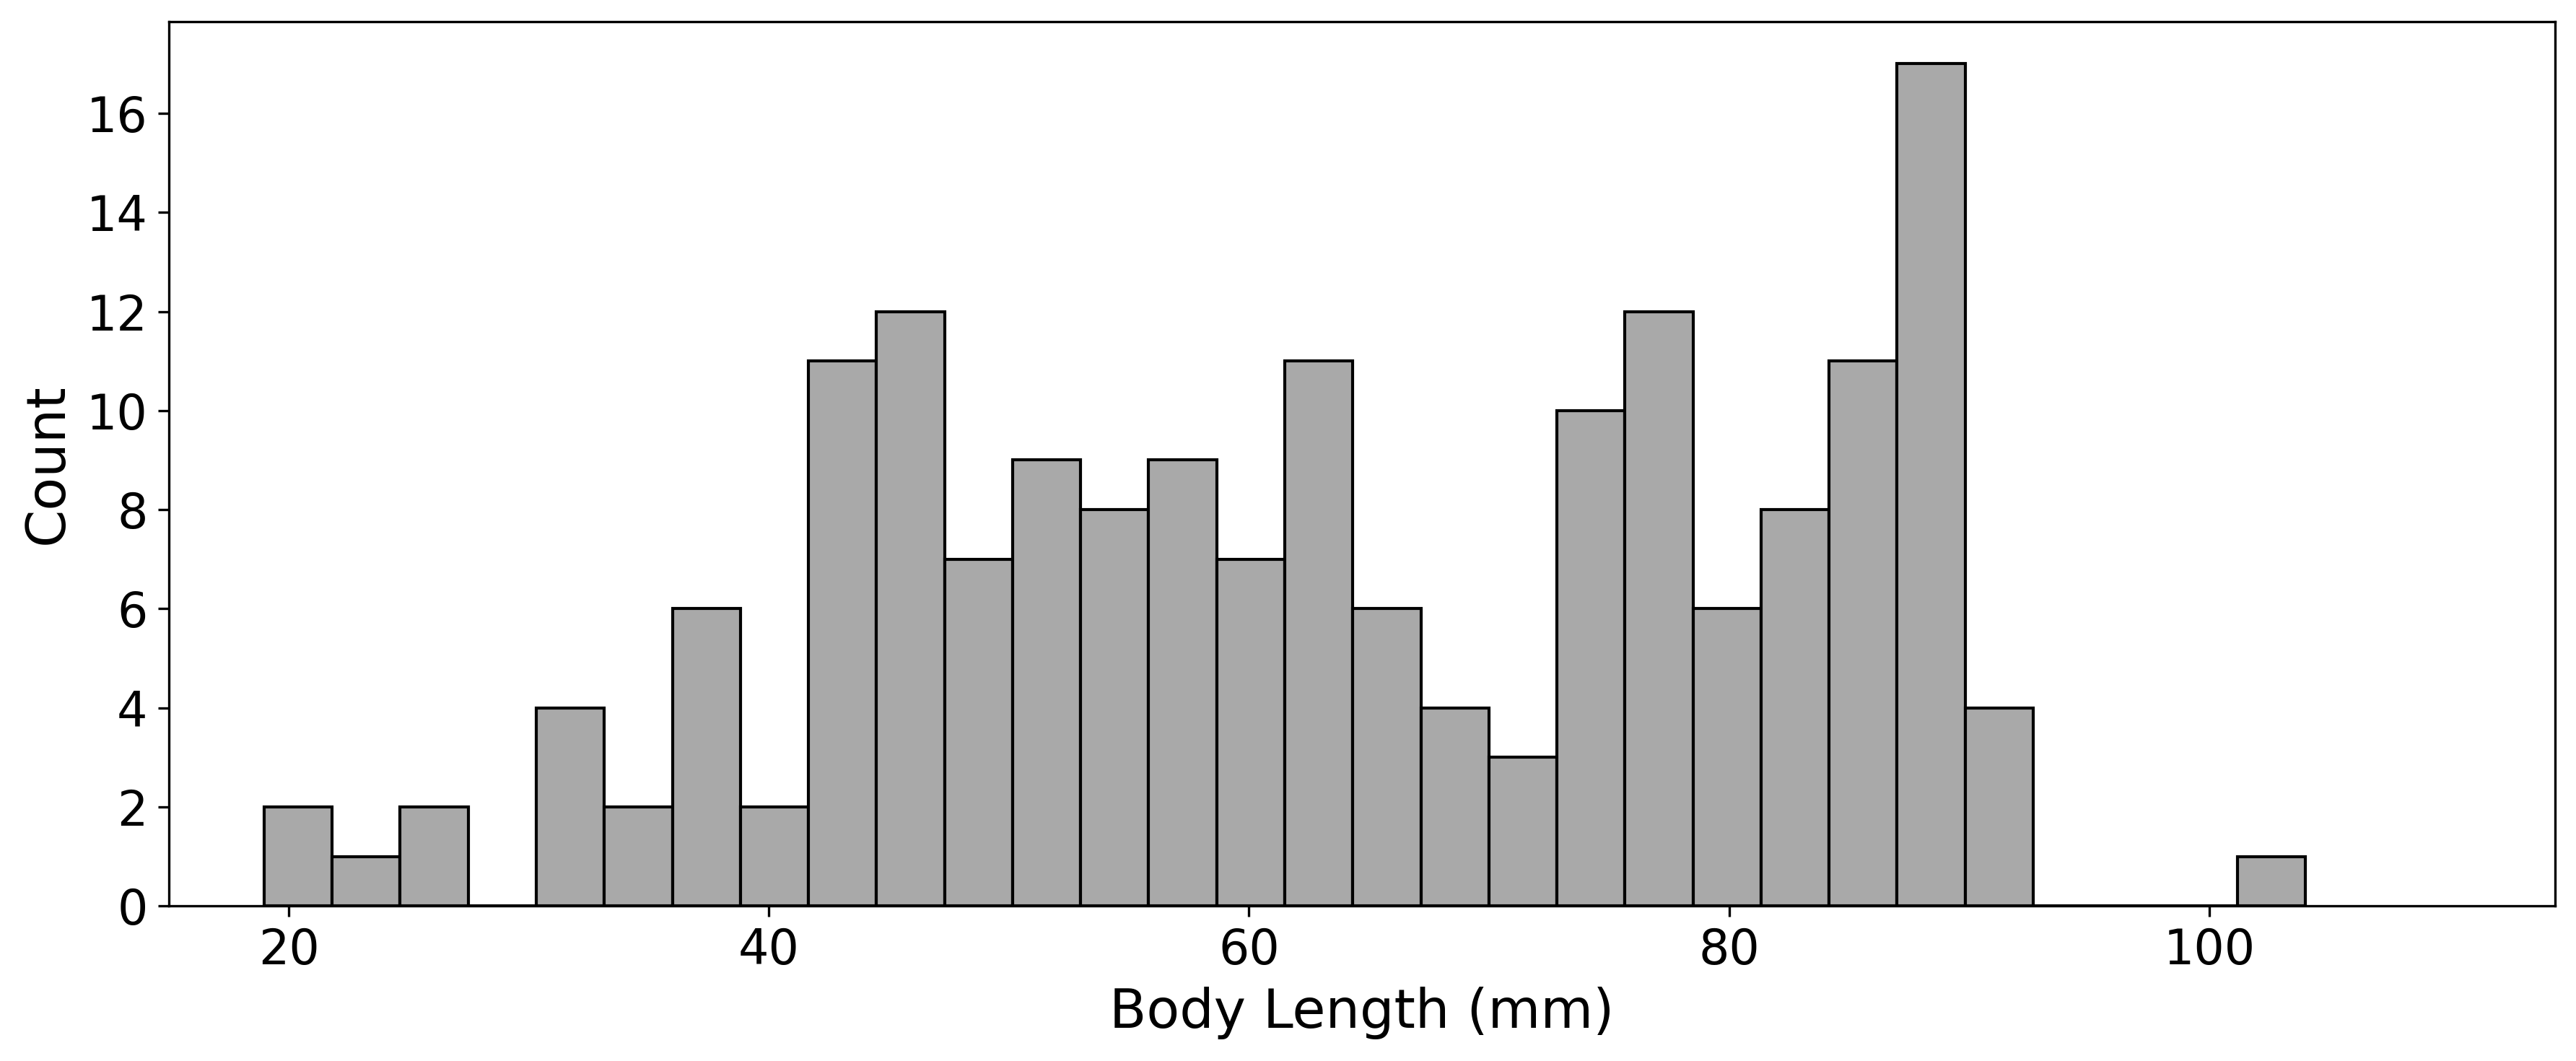

In [90]:
body_lengths = df_episodes.groupby(["id", "individual"])["body_length"].first().to_dict()
# Plot histogram of body lengths
length_values = [v for v in body_lengths.values() if not pd.isna(v)]
plt.figure(figsize=(12, 5), dpi=300)
plt.hist(length_values, bins=30, color='darkgray', edgecolor='black')
plt.xlim(15, max(length_values) * 1.1)
plt.xlabel("Body Length (mm)", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

In [91]:
arr = np.array(length_values, dtype=float)
count = int(np.count_nonzero(~np.isnan(arr)))
mn = float(np.nanmin(arr))
mx = float(np.nanmax(arr))
med = float(np.nanmedian(arr))
mean = float(np.nanmean(arr))

print(f"count: {count}")
print(f"min: {mn:.6f} mm")
print(f"max: {mx:.6f} mm")
print(f"median: {med:.6f} mm")
print(f"mean: {mean:.6f} mm")

count: 175
min: 18.975137 mm
max: 104.001972 mm
median: 63.000201 mm
mean: 63.544025 mm


In [287]:
# Find id with max mean body length
id_max_body_length = df_episodes.groupby('id')['body_length'].mean().idxmax()
max_body_length = df_episodes.groupby('id')['body_length'].mean().max()

print(f"ID with max mean body length: {id_max_body_length} ({max_body_length:.2f} mm)")

ID with max mean body length: 36_1_seq1 (104.03 mm)


## Movement Distributions (PLOT)

In [7]:
# Filter for travel and rest episodes with valid body_length and reasonable duration
final_df = df_episodes[
    (df_episodes['body_length'].notna()) &
    (
        ((df_episodes['behavior'] == 'travel') & (df_episodes['duration'] <= 2) &  (df_episodes['dist'] < 0.2)) |
        ((df_episodes['behavior'] == 'rest') & (df_episodes['duration'] <= 60))
    )
]

# Define size bins in millimeters
min_len = final_df['body_length'].min()
max_len = final_df['body_length'].max()
bin_width = 30  # mm
start = np.floor(min_len / bin_width) * bin_width
end = np.ceil(max_len / bin_width) * bin_width
bin_edges = np.arange(start, end + bin_width, bin_width)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Travel episodes: violin plot of durations by body length bin
travel_df = final_df[final_df['behavior'] == 'travel'].copy()
travel_df['bin'] = pd.cut(travel_df['body_length'], bins=bin_edges, labels=bin_centers, include_lowest=True)
travel_groups = travel_df.groupby('bin')['duration']
travel_groups_dist = travel_df.groupby('bin')['dist']

rest_df = final_df[final_df['behavior'] == 'rest'].copy()
rest_df['bin'] = pd.cut(rest_df['body_length'], bins=bin_edges, labels=bin_centers, include_lowest=True)
rest_groups = rest_df.groupby('bin')['duration']

C:\Users\eforb\AppData\Local\Temp\ipykernel_5704\1208413431.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ld.set_yticklabels([f"{y*1000:.0f}" for y in yt])
C:\Users\eforb\AppData\Local\Temp\ipykernel_5704\1208413431.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_rd.set_yticklabels([f"{y*1000:.0f}" for y in yt])


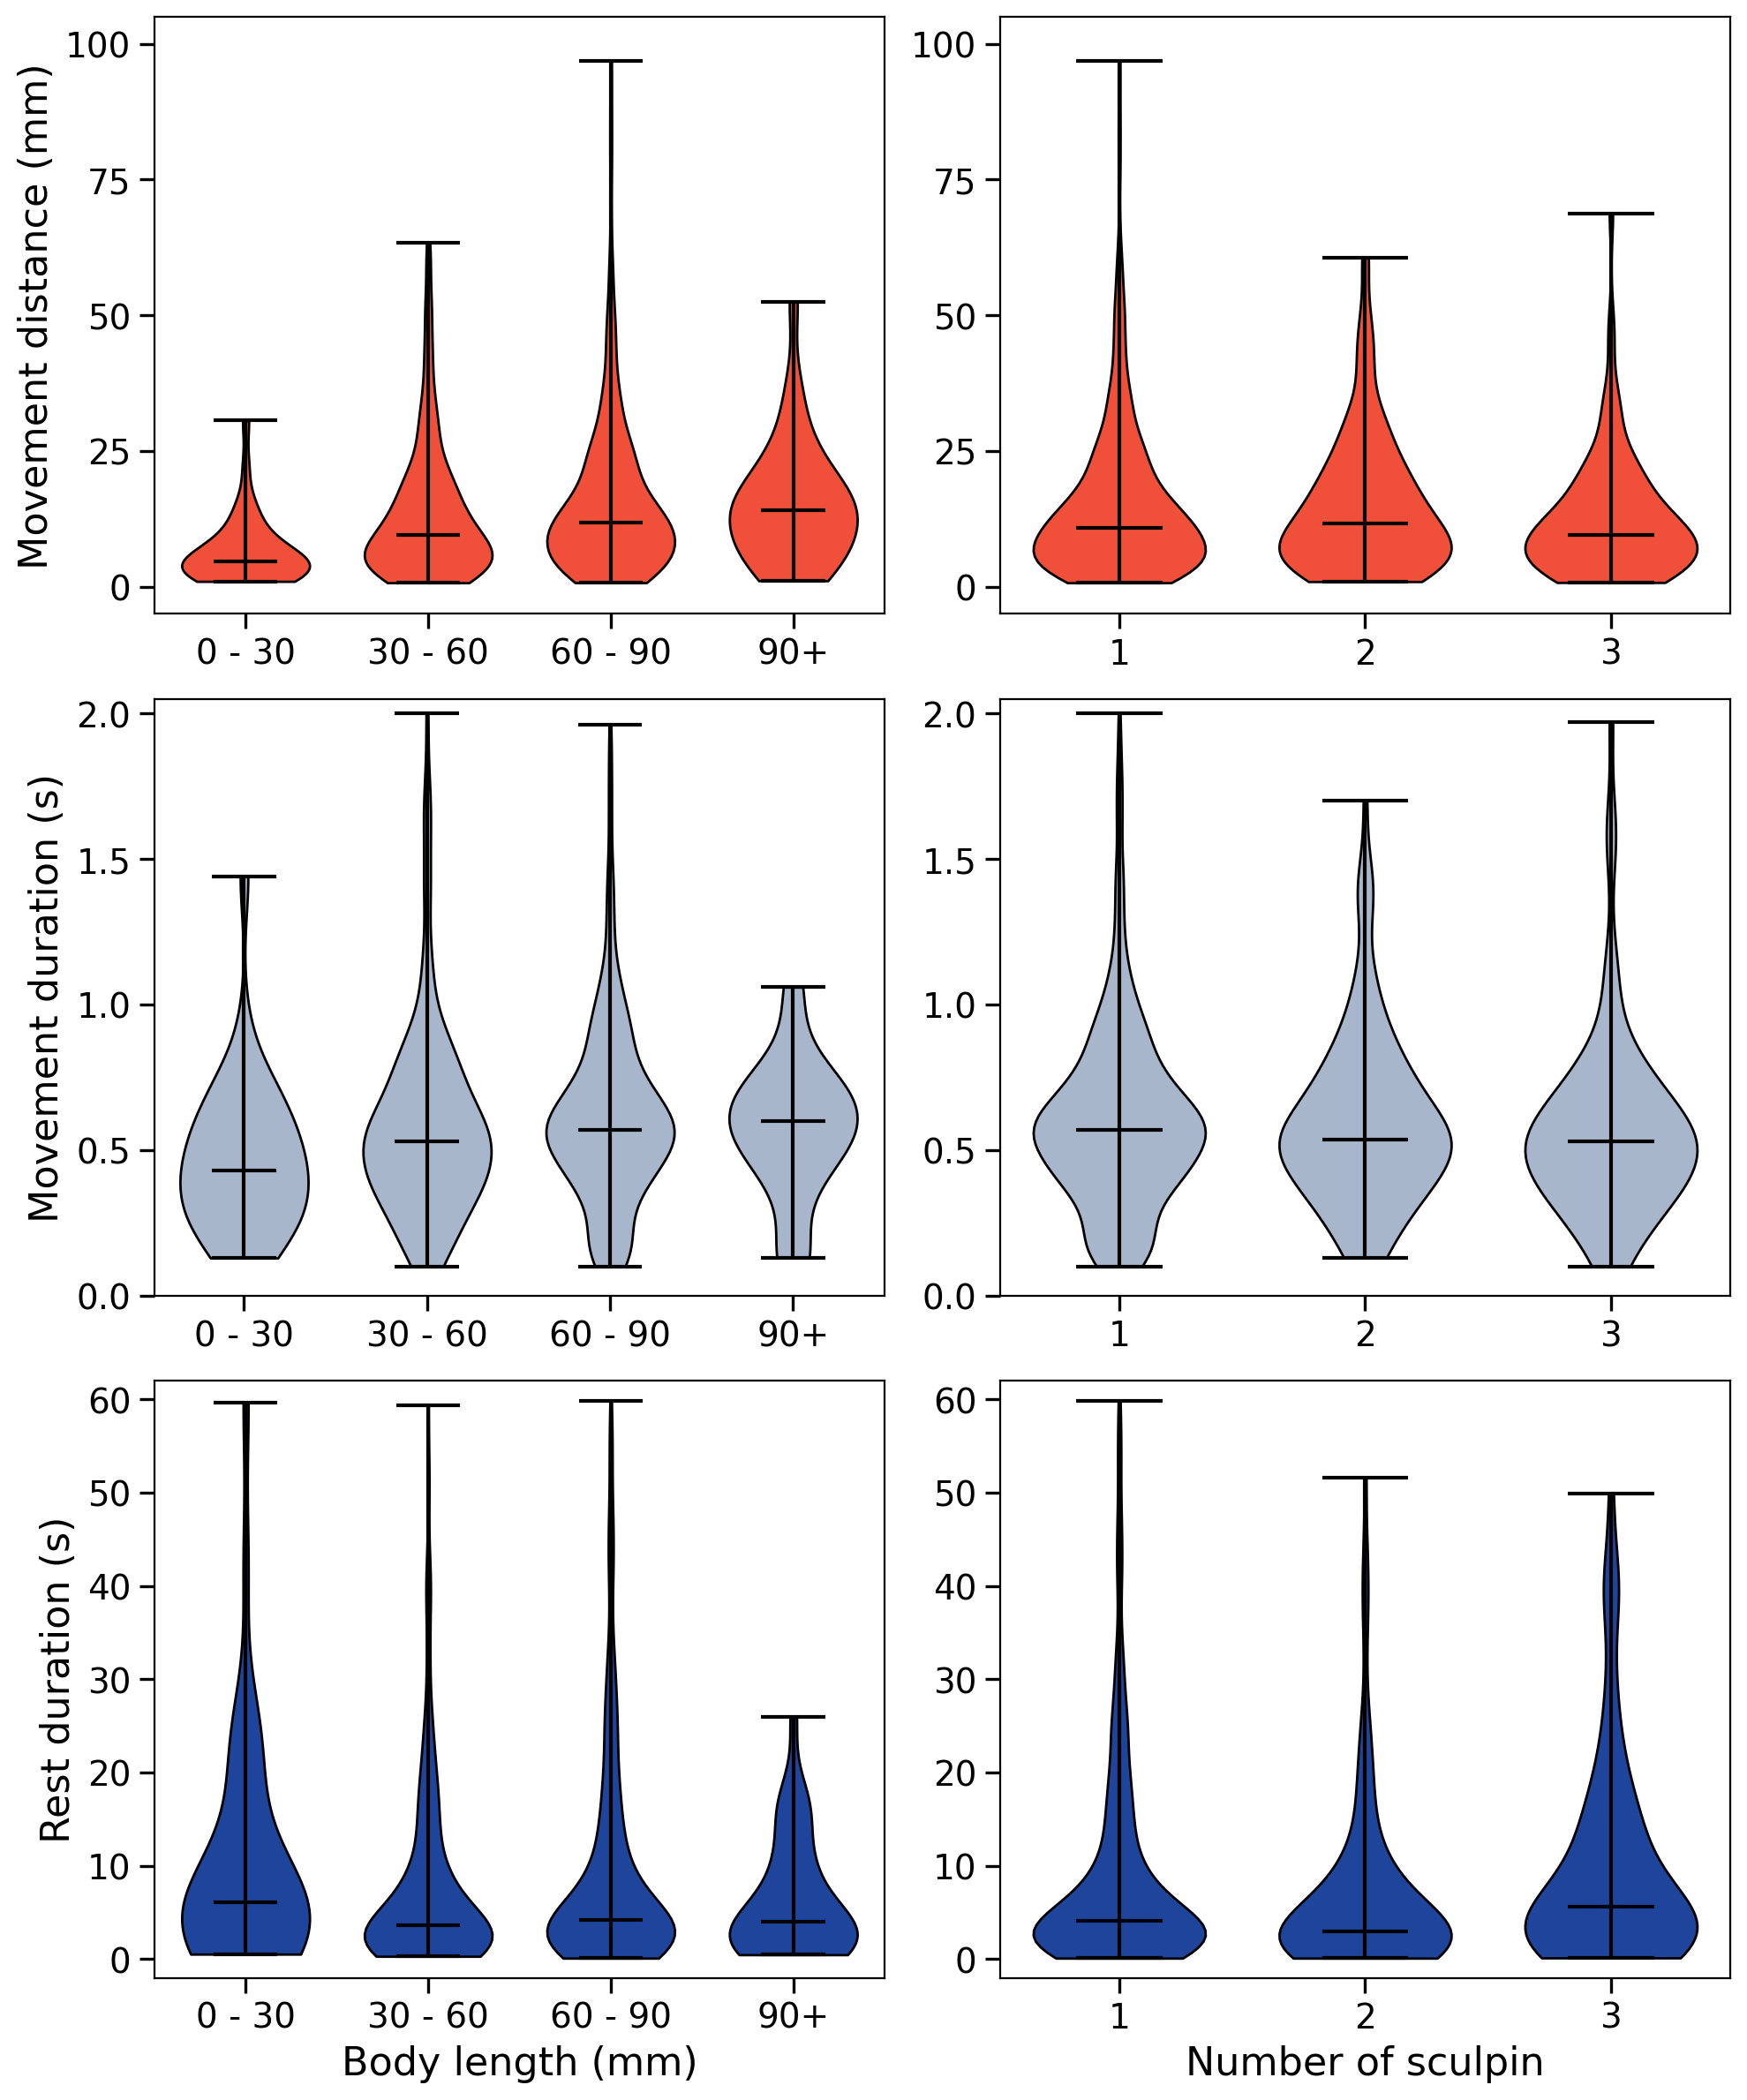

In [13]:
fig, axs = plt.subplots(3, 2, figsize=(10, 12), dpi=200)
# Left col = body size bins, Right col = number sculpin
ax_ld, ax_rd = axs[0, 0], axs[0, 1]  # row0: distances
ax_lm, ax_rm = axs[1, 0], axs[1, 1]  # row1: travel durations
ax_ls, ax_rs = axs[2, 0], axs[2, 1]  # row2: rest durations

# --- tick style ---
tick_fs = 14
tick_len = 6
tick_w = 1.2

# --- Prepare body-size positions ---
# use the same ordinal spacing as the right column (1,2,3,...)
pos_bins = [float(b) for b, g in travel_groups_dist if len(g) > 0]
N_bins = len(pos_bins)
positions_bins = [float(i + 1) for i in range(N_bins)]

# manually set x tick labels for left column
left_xticklabels = ['0 - 30', '30 - 60', '60 - 90', '90+'][:N_bins]

# --- Left col: by body size ---
# Distances by body-length bin (cell16)
data_dist_bins = [g.dropna().values for _, g in travel_groups_dist if len(g) > 0]
parts = ax_ld.violinplot(data_dist_bins, positions=positions_bins, widths=0.7, showmeans=False, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#F05039'); pc.set_edgecolor('black'); pc.set_alpha(1.0)
for key in ('cmaxes', 'cmins', 'cbars'):
    if key in parts: parts[key].set_color('black')
if 'cmedians' in parts:
    parts['cmedians'].set_edgecolor('black'); parts['cmedians'].set_linewidth(1.5)
ax_ld.set_ylabel('Movement distance (mm)', fontsize=16)
ax_ld.set_xlim(0.5, N_bins + 0.5)
ax_ld.set_xticks(positions_bins)
ax_ld.set_xticklabels(left_xticklabels, rotation=0)
ax_ld.set_ylim(-0.01, 0.21)
# multiply y tick labels by 1000 (convert from m to mm)
yt = ax_ld.get_yticks()
ax_ld.set_yticklabels([f"{y*1000:.0f}" for y in yt])

# Travel duration by body-length bin (cell18)
travel_groups_dur = travel_df.groupby('bin')['duration']
data_dur_bins = [g.dropna().values for _, g in travel_groups_dur if len(g) > 0]
parts = ax_lm.violinplot(data_dur_bins, positions=positions_bins, widths=0.7, showmeans=False, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#A8B6CC'); pc.set_edgecolor('black'); pc.set_alpha(1.0)
for key in ('cmaxes', 'cmins', 'cbars'):
    if key in parts: parts[key].set_color('black')
if 'cmedians' in parts:
    parts['cmedians'].set_edgecolor('black'); parts['cmedians'].set_linewidth(1.5)
ax_lm.set_ylabel('Movement duration (s)', fontsize=16)
ax_lm.set_ylim(0, 2.05)
ax_lm.set_xlim(0.51, N_bins + 0.5)
ax_lm.set_xticks(positions_bins)
ax_lm.set_xticklabels(left_xticklabels, rotation=0)

# Rest duration by body-length bin (cell20)
rest_groups_bin = rest_df.groupby('bin')['duration']
data_rest_bins = [g.dropna().values for _, g in rest_groups_bin if len(g) > 0]
parts = ax_ls.violinplot(data_rest_bins, positions=positions_bins, widths=0.7, showmeans=False, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#1F449C'); pc.set_edgecolor('black'); pc.set_alpha(1.0)
for key in ('cmaxes', 'cmins', 'cbars'):
    if key in parts: parts[key].set_color('black')
if 'cmedians' in parts:
    parts['cmedians'].set_edgecolor('black'); parts['cmedians'].set_linewidth(1.5)
ax_ls.set_xlabel('Body length (mm)', fontsize=16); ax_ls.set_ylabel('Rest duration (s)', fontsize=16)
ax_ls.set_ylim(-2, 62)
ax_ls.set_xlim(0.5, N_bins + 0.5)
ax_ls.set_xticks(positions_bins)
ax_ls.set_xticklabels(left_xticklabels, rotation=0)

# --- Right col: by number of sculpin (n_fish) ---
# prepare n_fish groups
travel_groups_n_dist = [(k, g) for k, g in travel_df.groupby('n_fish')['dist']]
travel_groups_n_dur = [(k, g) for k, g in travel_df.groupby('n_fish')['duration']]
rest_groups_n = [(k, g) for k, g in rest_df.groupby('n_fish')['duration']]

# Distances by n_fish (cell17)
data = [g.dropna().values for _, g in travel_groups_n_dist if len(g) > 0]
positions = [float(k) for k, g in travel_groups_n_dist if len(g) > 0]
parts = ax_rd.violinplot(data, positions=positions, widths=0.7, showmeans=False, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#F05039'); pc.set_edgecolor('black'); pc.set_alpha(1.0)
if 'cmedians' in parts:
    parts['cmedians'].set_edgecolor('black'); parts['cmedians'].set_linewidth(1.5)
for key in ('cmaxes', 'cmins', 'cbars'):
    if key in parts: parts[key].set_color('black')
ymax = max(np.nanmax(d) if len(d) > 0 else 0 for d in data) * 1.1
ax_rd.set_ylim(-0.01, 0.21)
ax_rd.set_xticks(positions); ax_rd.set_xticklabels([f"{int(p)}" for p in positions])
# multiply y tick labels by 1000 (convert from m to mm)
yt = ax_rd.get_yticks()
ax_rd.set_yticklabels([f"{y*1000:.0f}" for y in yt])

# Travel durations by n_fish (cell19)
data = [g.dropna().values for _, g in travel_groups_n_dur if len(g) > 0]
positions = [float(k) for k, g in travel_groups_n_dur if len(g) > 0]
parts = ax_rm.violinplot(data, positions=positions, widths=0.7, showmeans=False, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#A8B6CC'); pc.set_edgecolor('black'); pc.set_alpha(1.0)
if 'cmedians' in parts:
    parts['cmedians'].set_edgecolor('black'); parts['cmedians'].set_linewidth(1.5)
for key in ('cmaxes', 'cmins', 'cbars'):
    if key in parts: parts[key].set_color('black')
ax_rm.set_ylim(0, 2.05)
ax_rm.set_xticks(positions); ax_rm.set_xticklabels([f"{int(p)}" for p in positions])

# Rest durations by n_fish (cell21)
data = [g.dropna().values for _, g in rest_groups_n if len(g) > 0]
positions = [float(k) for k, g in rest_groups_n if len(g) > 0]
parts = ax_rs.violinplot(data, positions=positions, widths=0.7, showmeans=False, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#1F449C'); pc.set_edgecolor('black'); pc.set_alpha(1.0)
if 'cmedians' in parts:
    parts['cmedians'].set_edgecolor('black'); parts['cmedians'].set_linewidth(1.5)
for key in ('cmaxes', 'cmins', 'cbars'):
    if key in parts: parts[key].set_color('black')
ax_rs.set_xlabel('Number of sculpin', fontsize=16)
ax_rs.set_ylim(-2, 62)
ax_rs.set_xticks(positions); ax_rs.set_xticklabels([f"{int(p)}" for p in positions])

# make all x/y ticks larger on all subplots
for a in [ax_ld, ax_lm, ax_ls, ax_rd, ax_rm, ax_rs]:
    a.tick_params(axis='both', labelsize=tick_fs, length=tick_len, width=tick_w)

plt.tight_layout()
plt.show()


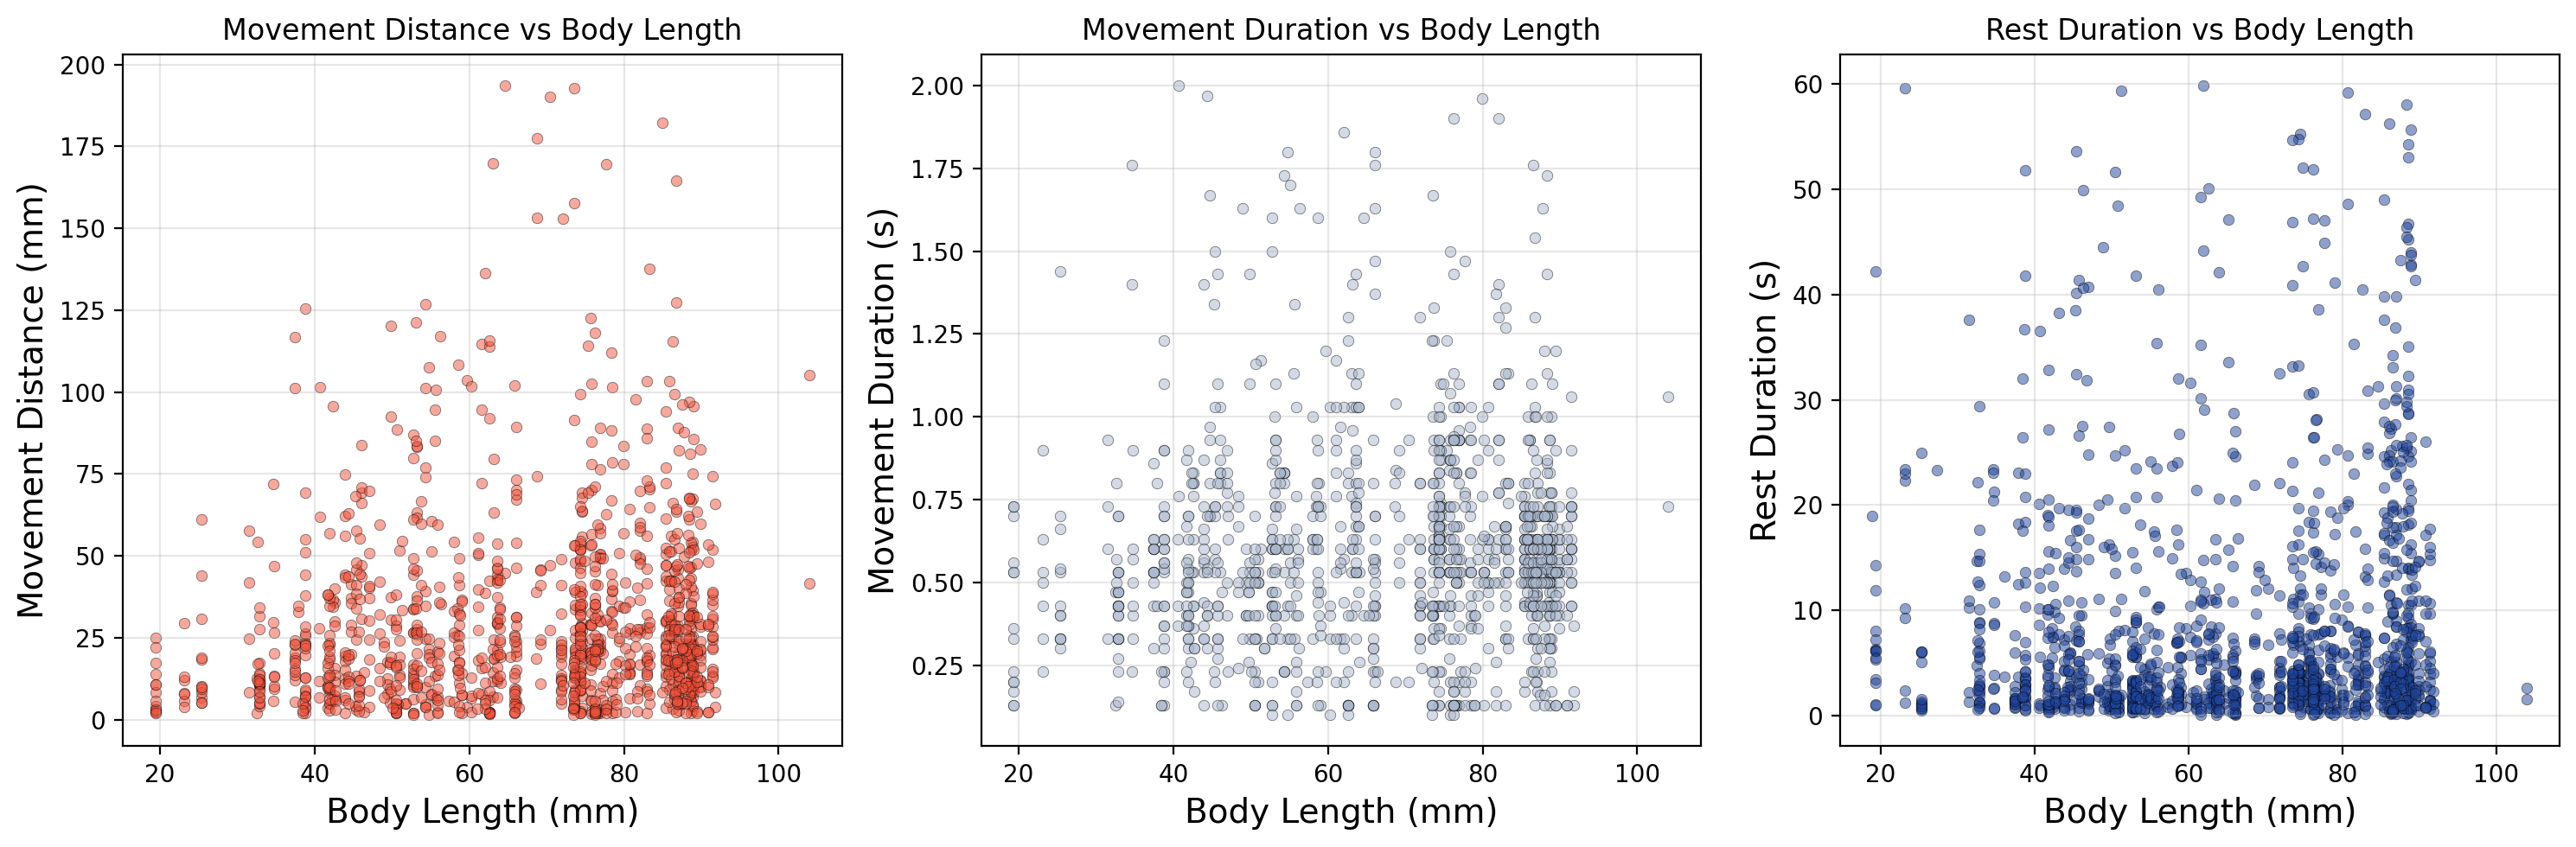

In [14]:
# Scatter plots for movement metrics by body length (individual data points)
fig, axs = plt.subplots(1, 3, figsize=(15, 5), dpi=200)

# Left: Movement distances by body length
ax = axs[0]
travel_scatter = travel_df[['body_length', 'dist']].dropna()
ax.scatter(travel_scatter['body_length'], travel_scatter['dist'] * 1000, 
           alpha=0.5, s=20, edgecolors='k', linewidths=0.3, color='#F05039')
ax.set_xlabel('Body Length (mm)', fontsize=14)
ax.set_ylabel('Movement Distance (mm)', fontsize=14)
ax.set_title('Movement Distance vs Body Length')
ax.grid(alpha=0.3)

# Middle: Travel durations by body length
ax = axs[1]
ax.scatter(travel_scatter['body_length'], travel_df['duration'], 
           alpha=0.5, s=20, edgecolors='k', linewidths=0.3, color='#A8B6CC')
ax.set_xlabel('Body Length (mm)', fontsize=14)
ax.set_ylabel('Movement Duration (s)', fontsize=14)
ax.set_title('Movement Duration vs Body Length')
ax.grid(alpha=0.3)

# Right: Rest durations by body length
ax = axs[2]
rest_scatter = rest_df[['body_length', 'duration']].dropna()
ax.scatter(rest_scatter['body_length'], rest_scatter['duration'], 
           alpha=0.5, s=20, edgecolors='k', linewidths=0.3, color='#1F449C')
ax.set_xlabel('Body Length (mm)', fontsize=14)
ax.set_ylabel('Rest Duration (s)', fontsize=14)
ax.set_title('Rest Duration vs Body Length')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Movement Distributions (STATS)

In [8]:
# Calculate mean and std for travel distances, travel durations, and rest durations
travel_dist_mean = travel_df["dist"].mean()
travel_dist_std = travel_df["dist"].std()

travel_dur_mean = travel_df["duration"].mean()
travel_dur_std = travel_df["duration"].std()

rest_dur_mean = rest_df["duration"].mean()
rest_dur_std = rest_df["duration"].std()

print(f"Travel Distance: {travel_dist_mean:.6f} m ± {travel_dist_std:.6f} m ({travel_dist_mean*1000:.2f} ± {travel_dist_std*1000:.2f} mm)")
print(f"Travel Duration: {travel_dur_mean:.6f} s ± {travel_dur_std:.6f} s")
print(f"Rest Duration: {rest_dur_mean:.6f} s ± {rest_dur_std:.6f} s")

Travel Distance: 0.030152 m ± 0.028581 m (30.15 ± 28.58 mm)
Travel Duration: 0.599181 s ± 0.313848 s
Rest Duration: 8.813935 s ± 11.149071 s


In [10]:
def run_anova(df, dep, subset_name):
    df2 = df[[dep, "body_length", "n_fish"]].dropna()
    if len(df2) < 3:
        print(f"Not enough data for {subset_name} ANOVA")
        return
    try:
        mod = smf.ols(f"{dep} ~ body_length * C(n_fish)", data=df2).fit()
        anova = sm.stats.anova_lm(mod, typ=2)
        print(f"\nANOVA for {subset_name} ({dep}):")
        print(anova)
    except Exception as e:
        print(f"ANOVA failed for {subset_name}: {e}")

# Travel: distances and durations (use raw body_length)
travel = final_df[final_df["behavior"] == "travel"]
travel['dist'] = travel['dist'] * 1000  # Convert to mm
run_anova(travel, "dist", "travel distances")
run_anova(travel, "duration", "travel durations")

# Rest: durations
rest = final_df[final_df["behavior"] == "rest"]
run_anova(rest, "duration", "rest durations")



ANOVA for travel distances (dist):
                              sum_sq      df          F    PR(>F)
C(n_fish)                1985.937017     2.0   1.230191  0.292616
body_length             10044.739574     1.0  12.444453  0.000436
body_length:C(n_fish)    2535.268859     2.0   1.570476  0.208386
Residual               941155.554569  1166.0        NaN       NaN

ANOVA for travel durations (duration):
                           sum_sq      df         F    PR(>F)
C(n_fish)                0.064302     2.0  0.326403  0.721580
body_length              0.312645     1.0  3.174027  0.075078
body_length:C(n_fish)    0.073135     2.0  0.371240  0.689960
Residual               114.852161  1166.0       NaN       NaN

ANOVA for rest durations (duration):
                              sum_sq      df         F    PR(>F)
C(n_fish)                 544.667649     2.0  2.201301  0.111037
body_length               479.646109     1.0  3.877026  0.049146
body_length:C(n_fish)     233.989298     2.0  0.945

In [11]:
# Prepare data for GLM
glm_data = travel_df[['dist', 'body_length', 'n_fish']].copy()
glm_data['dist'] = glm_data['dist'] * 1000  # Convert to mm
glm_data.columns = ['travel_dist', 'body_length', 'n_fish']

rest_data = rest_df[['duration', 'body_length', 'n_fish']].copy()
rest_data.columns = ['rest_dur', 'body_length', 'n_fish']

# GLM: Travel distance ~ body length (using Gaussian distribution with identity link)
glm_travel_dist = smf.glm('travel_dist ~ body_length', data=glm_data, family=sm.families.Gaussian()).fit()
print(glm_travel_dist.summary())
print("\n")

# GLM: Travel duration ~ body length (using Gaussian distribution with identity link)
glm_travel_dur = smf.glm('travel_dur ~ body_length', data=travel_df[['duration', 'body_length', 'n_fish']].rename(columns={'duration': 'travel_dur'}), family=sm.families.Gaussian()).fit()
print(glm_travel_dur.summary())
print("\n")

# GLM: Rest duration ~ body length (using Gaussian distribution with identity link)
glm_rest_dur = smf.glm('rest_dur ~ body_length', data=rest_data, family=sm.families.Gaussian()).fit()
print(glm_rest_dur.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:            travel_dist   No. Observations:                 1172
Model:                            GLM   Df Residuals:                     1170
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                          808.27
Method:                          IRLS   Log-Likelihood:                -5585.2
Date:                Wed, 25 Mar 2026   Deviance:                   9.4568e+05
Time:                        21:06:39   Pearson chi2:                 9.46e+05
No. Iterations:                     3   Pseudo R-squ. (CS):            0.01144
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      19.3360      3.061      6.318      

In [1]:
# Scatter plots for movement metrics by body length (individual data points)
fig, axs = plt.subplots(3, 1, figsize=(6, 12), dpi=200)

# Common x range for fits
x_fit = np.linspace(
    min(travel["body_length"].min(), rest_df["body_length"].min()),
    max(travel["body_length"].max(), rest_df["body_length"].max()),
    200
)
x_fit_df = pd.DataFrame({"body_length": x_fit})

# Left: Movement distances by body length
ax = axs[0]
travel_scatter = travel[['body_length', 'dist']].dropna()
ax.scatter(travel_scatter['body_length'], travel_scatter['dist'], 
           alpha=0.2, s=20, edgecolors='k', linewidths=0.01, color='#F05039')

pred = glm_travel_dist.get_prediction(x_fit_df).summary_frame()
ax.plot(x_fit, pred["mean"], color="black", lw=2)
ax.fill_between(x_fit, pred["lower"], pred["upper"], 
                color="black", alpha=0.2)

ax.set_xlabel('Body Length (mm)', fontsize=14)
ax.set_ylabel('Movement Distance (mm)', fontsize=14)
ax.grid(alpha=0.3)

# Middle: Travel durations by body length
ax = axs[1]
ax.scatter(travel_scatter['body_length'], travel_df['duration'], 
           alpha=0.2, s=20, edgecolors='k', linewidths=0.01, color='#A8B6CC')

pred = glm_travel_dur.get_prediction(x_fit_df).summary_frame()
ax.plot(x_fit, pred["mean"], color="black", lw=2)
ax.fill_between(x_fit, pred["mean_ci_lower"], pred["mean_ci_upper"], 
                color="black", alpha=0.2)

ax.set_xlabel('Body Length (mm)', fontsize=14)
ax.set_ylabel('Movement Duration (s)', fontsize=14)
ax.grid(alpha=0.3)

# Right: Rest durations by body length
ax = axs[2]
rest_scatter = rest_df[['body_length', 'duration']].dropna()
ax.scatter(rest_scatter['body_length'], rest_scatter['duration'], 
           alpha=0.2, s=20, edgecolors='k', linewidths=0.01, color='#1F449C')

pred = glm_rest_dur.get_prediction(x_fit_df).summary_frame()
ax.plot(x_fit, pred["mean"], color="black", lw=2)
ax.fill_between(x_fit, pred["mean_ci_lower"], pred["mean_ci_upper"], 
                color="black", alpha=0.2)

ax.set_xlabel('Body Length (mm)', fontsize=14)
ax.set_ylabel('Rest Duration (s)', fontsize=14)
ax.grid(alpha=0.3)



# Calculate upper and lower bounds for the ribbon
df['upper'] = df['mean'] + df['variance']
df['lower'] = df['mean'] - df['variance']

plt.figure(figsize=(10, 6))
plt.plot(df['x'], df['mean'], label='Mean')
plt.fill_between(df['x'], df['lower'], df['upper'], color='b', alpha=0.2, label='Variance Ribbon')
plt.xlabel('X')
plt.ylabel('Value')
plt.title('Mean with Variance Ribbon')
plt.legend()
plt.show()



plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## Encounter Rates (Search)

In [736]:
def AINT(dist, rad):
    if dist >= 2 * rad:
        return 0.0
    if dist <= 0:
        return np.pi * rad ** 2
    part1 = 2 * rad ** 2 * np.arccos(dist / (2 * rad))
    part2 = (dist / 2) * np.sqrt(4 * rad ** 2 - dist ** 2)
    return part1 - part2
def IS2D(dens, dist, rad, time):
    area = np.pi * rad**2 - np.real(AINT(dist, rad))
    return dens * area / time

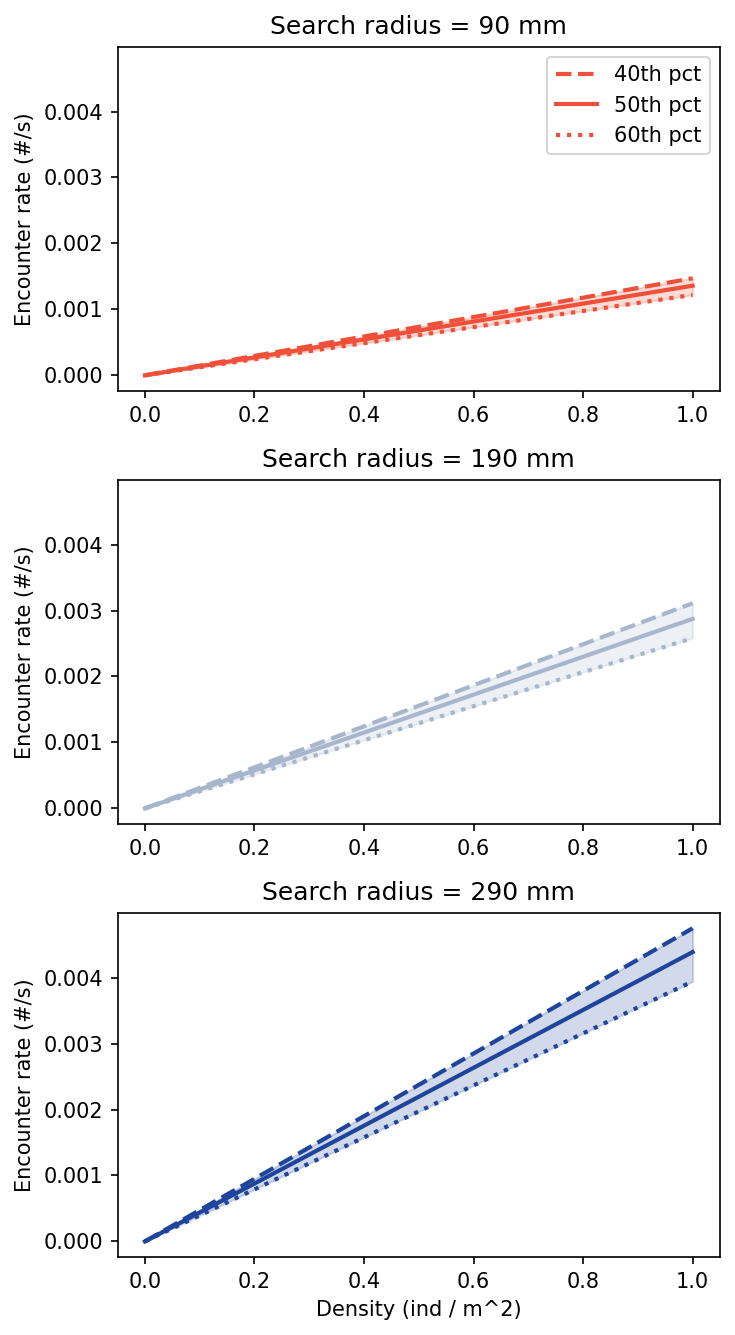

In [ ]:


# encounter rate panel — fix plotting by using a dense density vector and consistent units (m)
dens = np.linspace(0.0, 1.0, 200)  # density range (individuals per m^2)
radii_mm = [90, 190, 290]
radii_m = [r/1000.0 for r in radii_mm]  # convert mm -> m

# compute distance percentiles from travel episodes (meters)
distances = travel_df["dist"].dropna().to_numpy()
if distances.size == 0:
    distances = np.array([mean_dist])  # fallback
dist_p = np.percentile(distances, [40, 50, 60])

# compute cycle times = travel duration + subsequent rest duration within same id/individual
cycle_times = []
if "df_episodes" in globals():
    ep = df_episodes.sort_values(["id", "individual", "inittime"]).reset_index(drop=True)
    for (ID, ind), g in ep.groupby(["id", "individual"]):
        g = g.reset_index(drop=True)
        for i in range(len(g)-1):
            if g.loc[i, "behavior"] == "travel" and g.loc[i+1, "behavior"] == "rest":
                t = g.loc[i, "duration"] + g.loc[i+1, "duration"]
                if not pd.isna(t):
                    cycle_times.append(t)
# fallback to travel durations if no cycle times found
if len(cycle_times) == 0:
    cycle_times = travel_df["duration"].dropna().to_list()
if len(cycle_times) == 0:
    cycle_times = [mean_time]

time_p = np.percentile(np.array(cycle_times), [40, 50, 60])

panel_colors = ["#F05039", "#A8B6CC", "#1F449C"]
labels = ["40th pct", "50th pct", "60th pct"]
linestyle_map = {0: "--", 1: "-", 2: ":"}  # index -> linestyle for 40th,50th,60th

fig, axs = plt.subplots(3, 1, figsize=(5, 9), sharey=True, dpi=150)
for ax, r_m, col in zip(axs, radii_m, panel_colors):
    # compute rates for percentiles (dens is array => IS2D broadcasts)
    rates_list = [IS2D(dens, d, r_m, t) for d, t in zip(dist_p, time_p)]
    # shade between 40th and 60th
    ax.fill_between(dens, rates_list[0], rates_list[2], color=col, alpha=0.2)
    # plot lines
    for idx, (rates, lab) in enumerate(zip(rates_list, labels)):
        ax.plot(dens, rates, lw=2, color=col, linestyle=linestyle_map[idx], label=lab)
    if ax is axs[-1]:
        ax.set_xlabel("Density (ind / m^2)")
    ax.set_ylabel("Encounter rate (#/s)")
    ax.set_title(f"Search radius = {r_m*1000:.0f} mm")
    if ax is axs[0]:
        ax.legend()

plt.tight_layout()
plt.show()

## Strikes

In [4]:
strikes_path = "Frame/strikes.csv"
strikes = pd.read_csv(strikes_path)

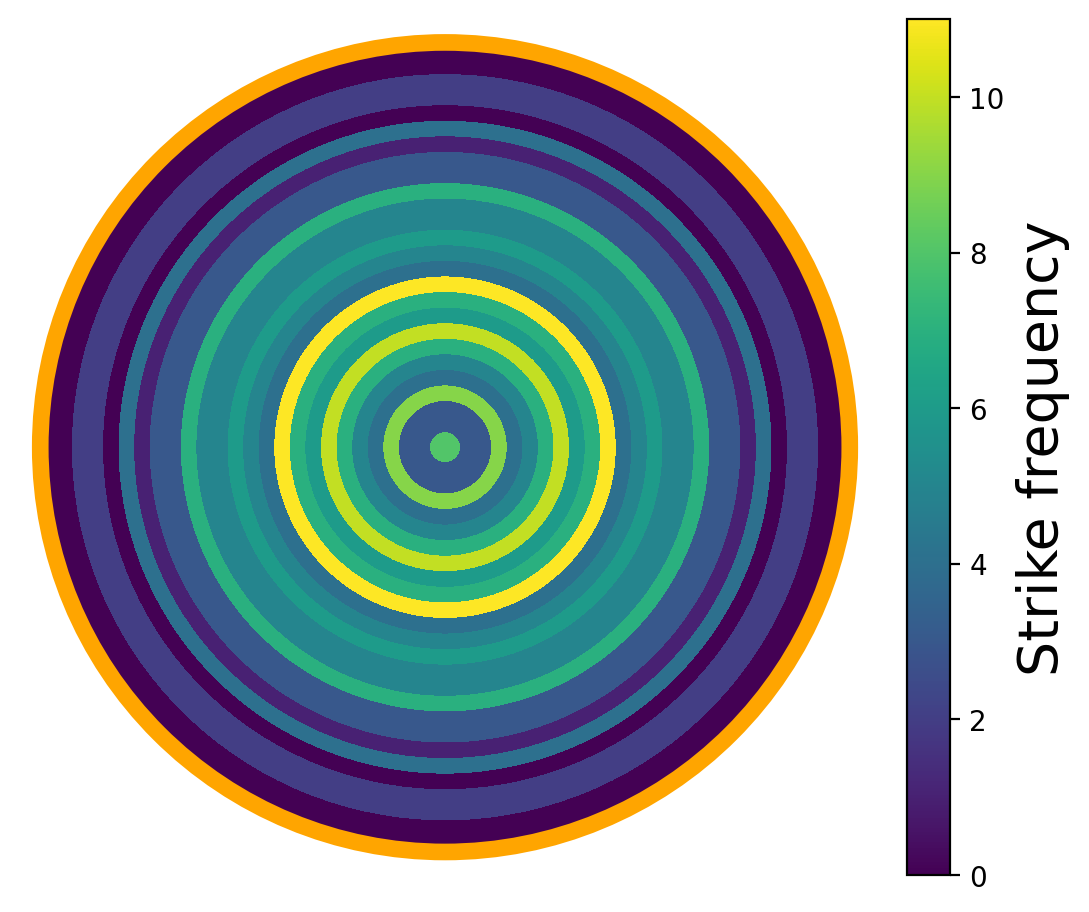

121
0.05103937588838497
0.0481170612450805
0.03003314532598148
0.1313962365850033
0.0017356198380682


In [6]:
radius = 0.13
dists = strikes["dist"].to_numpy()

# bin edges every 0.01 up to include the larger of radius or observed max distance
outer_limit = 0.13
bin_edges = np.arange(0.0, outer_limit + 1e-9, 0.005)
counts, _ = np.histogram(dists, bins=bin_edges)

# colormap for inside-circle bins
cmap = plt.cm.viridis
vmax = max(1, counts.max())
norm = plt.Normalize(vmin=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(6, 6),dpi=200)
ax.set_aspect("equal")

# draw annular bins as full 360-degree wedges with no outlines
for i in range(len(bin_edges) - 1):
    inn = bin_edges[i]
    out = bin_edges[i + 1]
    if out <= radius:
        color = cmap(norm(counts[i]))
    else:
        color = "orange"
    w = plt.matplotlib.patches.Wedge(
        (0, 0), out, 0, 360, width=(out - inn),
        facecolor=color, edgecolor='none', linewidth=0, antialiased=False, zorder=0
    )
    ax.add_patch(w)

# circle boundary at radius in orange
circ = plt.matplotlib.patches.Circle((0, 0), radius, fill=False, edgecolor="orange", linewidth=6, zorder=2)
ax.add_patch(circ)

# plot mean strike distance as a red circle
mean_dist = np.nanmean(dists) if len(dists) > 0 else np.nan
median_dist = np.nanmedian(dists) if len(dists) > 0 else np.nan
std_dist = np.nanstd(dists) if len(dists) > 0 else np.nan
# if not np.isnan(mean_dist):
#     mean_circ = plt.matplotlib.patches.Circle((0, 0), mean_dist, fill=False, edgecolor="red", linewidth=2.5, zorder=3)
#     ax.add_patch(mean_circ)

# colorbar for counts (only reflects inside-circle bin counts)
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array(counts)
cb = plt.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('Strike frequency', fontsize=20)

# ensure limits include mean circle
lim = max(outer_limit, mean_dist if not np.isnan(mean_dist) else outer_limit) * 1.05
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.set_xticks([])
ax.set_yticks([])

# remove square border (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

max_dist = np.nanmax(dists) if len(dists) > 0 else np.nan
min_dist = np.nanmin(dists) if len(dists) > 0 else np.nan

print(len(strikes))
print(mean_dist)
print(median_dist)
print(std_dist)
print(max_dist)
print(min_dist)

In [18]:
# Calculate max and min body length in strikes dataset
max_length = strikes['body_length'].max()
min_length = strikes['body_length'].min()

print(f"Maximum body length in strikes: {max_length:.2f} mm")
print(f"Minimum body length in strikes: {min_length:.2f} mm")

Maximum body length in strikes: 104.03 mm
Minimum body length in strikes: 34.77 mm


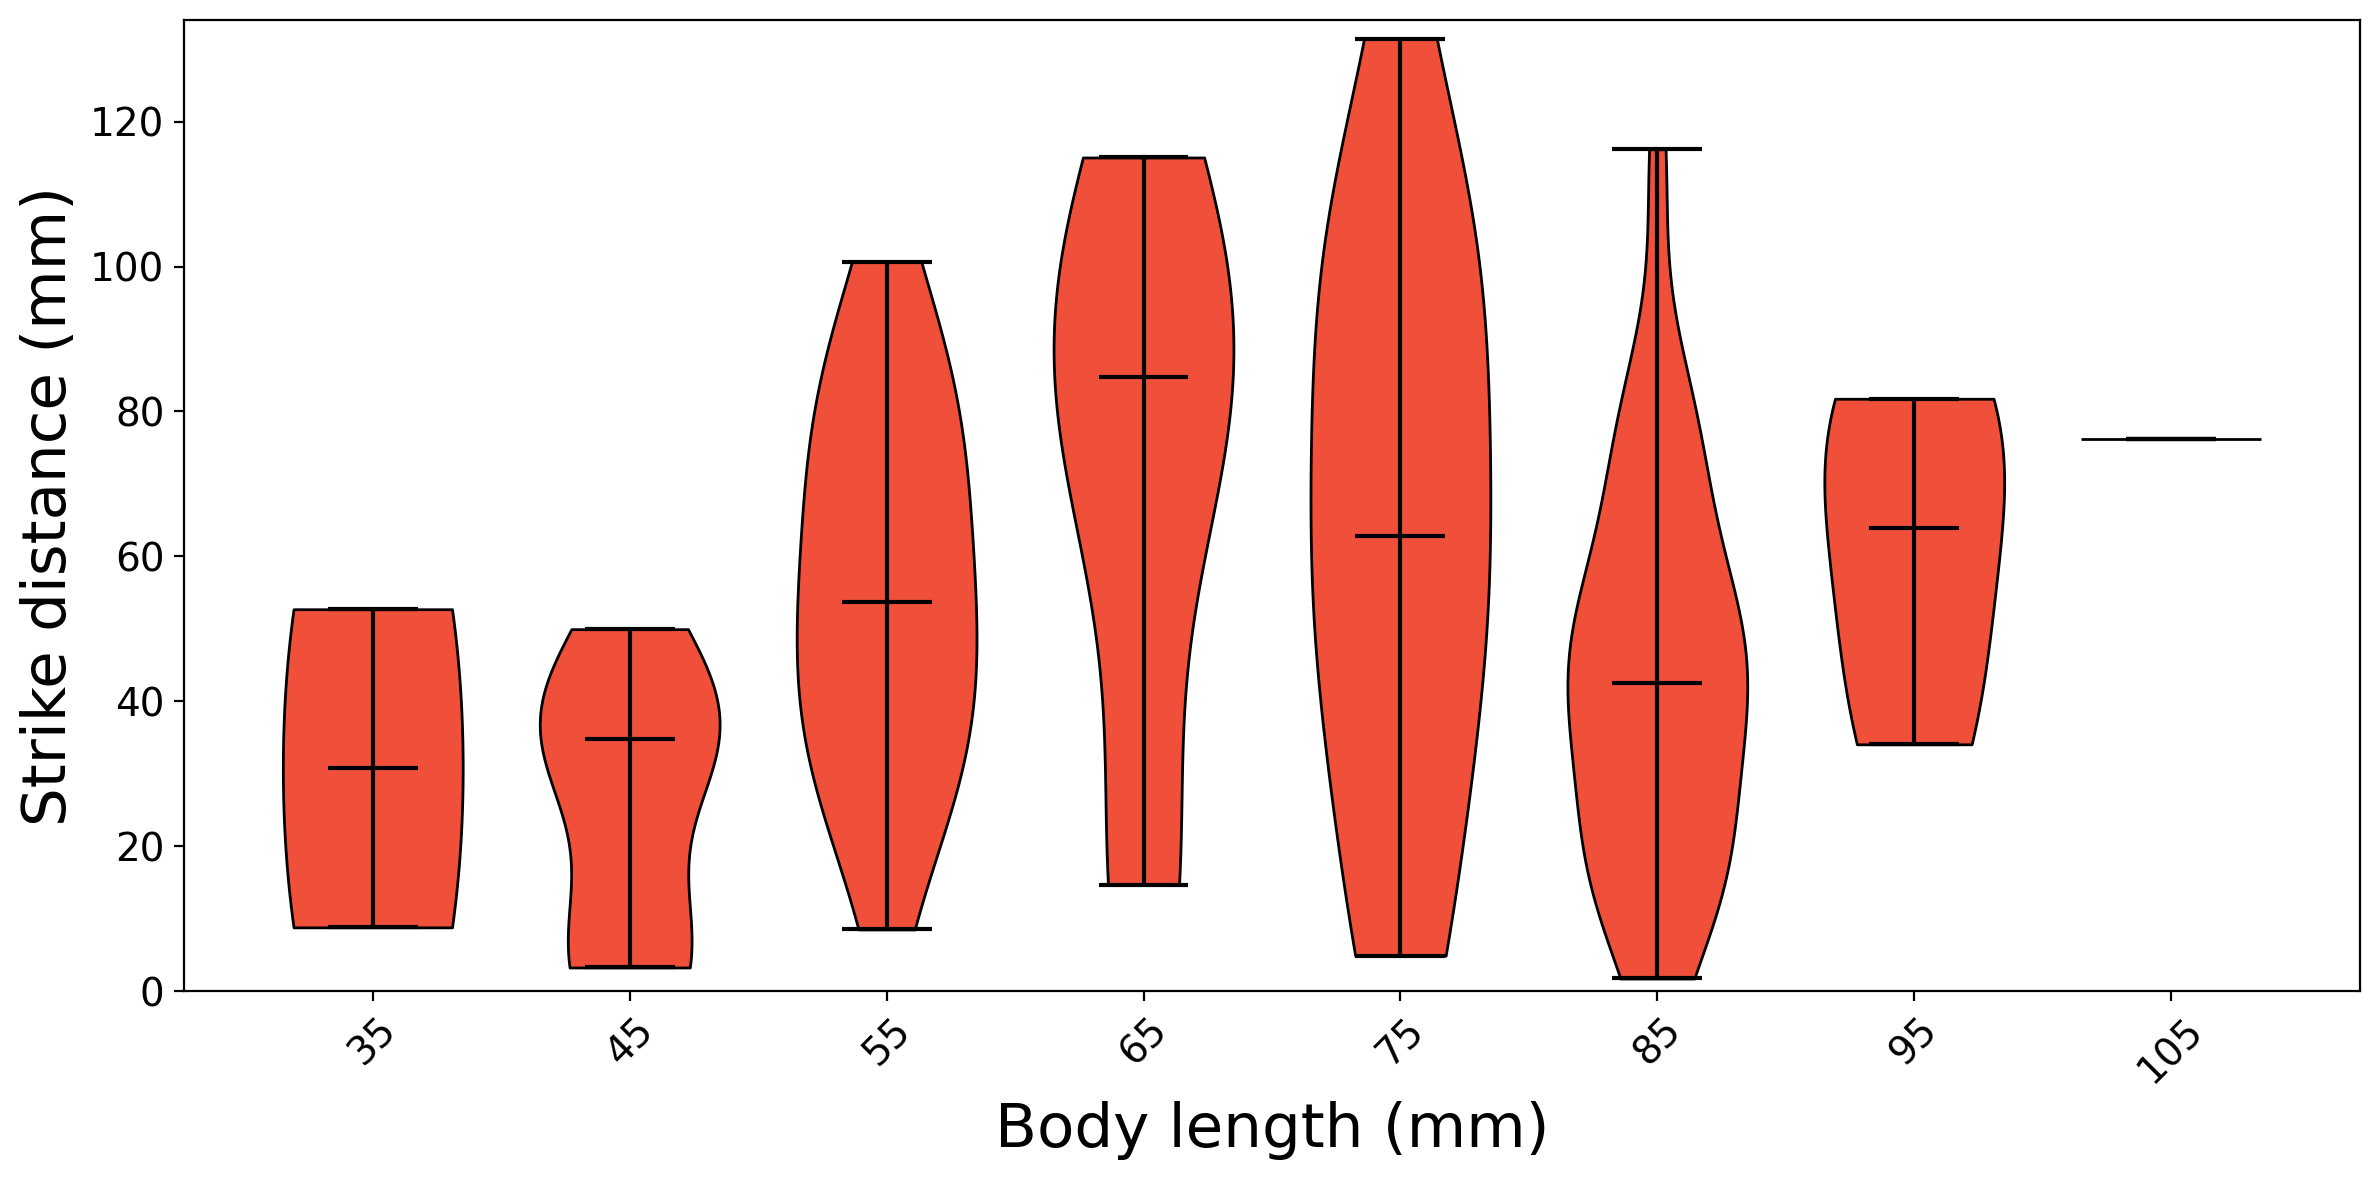

In [20]:
# two-panel violin plot of strike distances by body-size bins (20 mm) and by n_fish
# uses existing variables: strikes, bin_width (20), min_len, max_len, cmap from above imports

# Prepare data
strike_df = strikes.copy()
strike_df = strike_df[strike_df["body_length"].notna()].copy()
strike_df["dist_mm"] = strike_df["dist"] * 1000.0

# Body-size bins (20 mm)
bw = 10
start = np.floor(min_length / bw) * bw
end = np.ceil(max_length / bw) * bw
bs_edges = np.arange(start, end + bw, bw)
bs_centers = (bs_edges[:-1] + bs_edges[1:]) / 2.0
strike_df["size_bin"] = pd.cut(strike_df["body_length"], bins=bs_edges, labels=bs_centers, include_lowest=True)

# Prepare violin data for body-size bins
size_groups = [(float(k), g["dist_mm"]) for k, g in strike_df.groupby("size_bin") if len(g) > 0]
size_positions = [i + 1 for i in range(len(size_groups))]
size_labels = [f"{int(k)}" for k, _ in size_groups]
size_data = [g.dropna().values for _, g in size_groups]

# Plot
fig, ax = plt.subplots(figsize=(12, 6), dpi=200)

# Left: by body size
if len(size_data) > 0:
    parts = ax.violinplot(size_data, positions=size_positions, widths=0.7, showmeans=False, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor('#F05039'); pc.set_edgecolor('black'); pc.set_alpha(1.0)
    for key in ('cmaxes', 'cmins', 'cbars'):
        if key in parts: parts[key].set_color('black')
    if 'cmedians' in parts:
        parts['cmedians'].set_edgecolor('black'); parts['cmedians'].set_linewidth(1.5)
ax.set_xlabel('Body length (mm)', fontsize=22)
ax.set_xticks(size_positions)
ax.set_xticklabels(size_labels, rotation=45, fontsize=14)
ax.set_ylabel('Strike distance (mm)', fontsize=22)

# Increase tick label sizes
ax.tick_params(axis='both', which='major', labelsize=14)

# tidy up y limits and layout
all_mm = strike_df["dist_mm"].dropna()
if not all_mm.empty:
    ylim_top = all_mm.max() * 1.02
    ax.set_ylim(0, ylim_top)

plt.tight_layout()
plt.show()

In [21]:
# GLM: body length ~ strike distance
glm_strike_bl = smf.glm(
    "body_length ~ dist_mm",
    data=strike_df[["body_length", "dist_mm"]].dropna(),
    family=sm.families.Gamma(link=sm.families.links.Log())).fit()

print(glm_strike_bl.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            body_length   No. Observations:                  121
Model:                            GLM   Df Residuals:                      119
Model Family:                   Gamma   Df Model:                            1
Link Function:                    Log   Scale:                        0.045270
Method:                          IRLS   Log-Likelihood:                -510.36
Date:                Wed, 22 Apr 2026   Deviance:                       6.1878
Time:                        10:14:53   Pearson chi2:                     5.39
No. Iterations:                     7   Pseudo R-squ. (CS):          0.0001007
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2998      0.038    112.737      0.0

In [23]:
strike_df["distper"] = strike_df["dist_mm"] / strike_df["body_length"]
# GLM: body length ~ strike distance
glm_strike_bl = smf.glm(
    "body_length ~ distper",
    data=strike_df[["body_length", "distper"]].dropna(),
    family=sm.families.Gamma(link=sm.families.links.Log())).fit()

print(glm_strike_bl.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            body_length   No. Observations:                  121
Model:                            GLM   Df Residuals:                      119
Model Family:                   Gamma   Df Model:                            1
Link Function:                    Log   Scale:                        0.040129
Method:                          IRLS   Log-Likelihood:                -504.18
Date:                Wed, 22 Apr 2026   Deviance:                       5.5785
Time:                        10:16:19   Pearson chi2:                     4.78
No. Iterations:                     8   Pseudo R-squ. (CS):             0.1180
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.4164      0.034    129.186      0.0